# Deep Learning Explainability + Five-Scenario Dashboard

This notebook keeps DL explainability (training curves, ROC, Grad-CAM, IG) and now adds five-scenario result comparison.


In [49]:
from pathlib import Path
import sys
import os
import json

import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image
from sklearn.metrics import confusion_matrix, roc_curve, auc, roc_auc_score
from sklearn.preprocessing import label_binarize

import torch


def is_project_root(p: Path) -> bool:
    return (p / 'src').is_dir() and (p / 'outputs').is_dir()


def find_project_root() -> Path:
    cwd = Path.cwd().resolve()
    for p in [cwd, *cwd.parents]:
        if is_project_root(p):
            return p
    for p in (Path.home() / 'Downloads').rglob('Retinal-OCT-Images'):
        if is_project_root(p):
            return p.resolve()
    raise FileNotFoundError('Cannot locate project root containing src/ and outputs/.')


PROJECT_ROOT = find_project_root()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))
os.chdir(PROJECT_ROOT)

from src.config import CLASS_NAMES
from src.deeplearning.models import build_model
from src.deeplearning.augmentations import build_transforms, IMAGENET_MEAN, IMAGENET_STD

CLASS_NAMES = list(CLASS_NAMES)
sns.set_theme(style='whitegrid')

print('PROJECT_ROOT =', PROJECT_ROOT)
print('cwd =', Path.cwd())


PROJECT_ROOT = /Users/rick/Downloads/Southampton/Computer Vision/CW2/code/Retinal-OCT-Images
cwd = /Users/rick/Downloads/Southampton/Computer Vision/CW2/code/Retinal-OCT-Images


,scenario,label,family,status,path
0,trad_raw_official,Traditional RAW Official,traditional,ok,/Users/rick/Downloads/Southampton/Computer Vis...
1,trad_raw_strict,Traditional RAW Strict,traditional,ok,/Users/rick/Downloads/Southampton/Computer Vis...
2,trad_processed_official,Traditional Processed Official,traditional,missing,
3,dl_processed_official,DL VGG16 Processed Official,deeplearning,ok,/Users/rick/Downloads/Southampton/Computer Vis...
4,dl_processed_strict,DL VGG16 Processed Strict,deeplearning,ok,/Users/rick/Downloads/Southampton/Computer Vis...


,label,accuracy,macro_f1,macro_precision,macro_recall
4,DL VGG16 Processed Strict,0.970149,0.965511,0.964641,0.966600
3,DL VGG16 Processed Official,0.963843,0.963732,0.963997,0.963843
0,Traditional RAW Official,0.959711,0.959805,0.962998,0.959711
1,Traditional RAW Strict,0.855721,0.835255,0.890536,0.835714


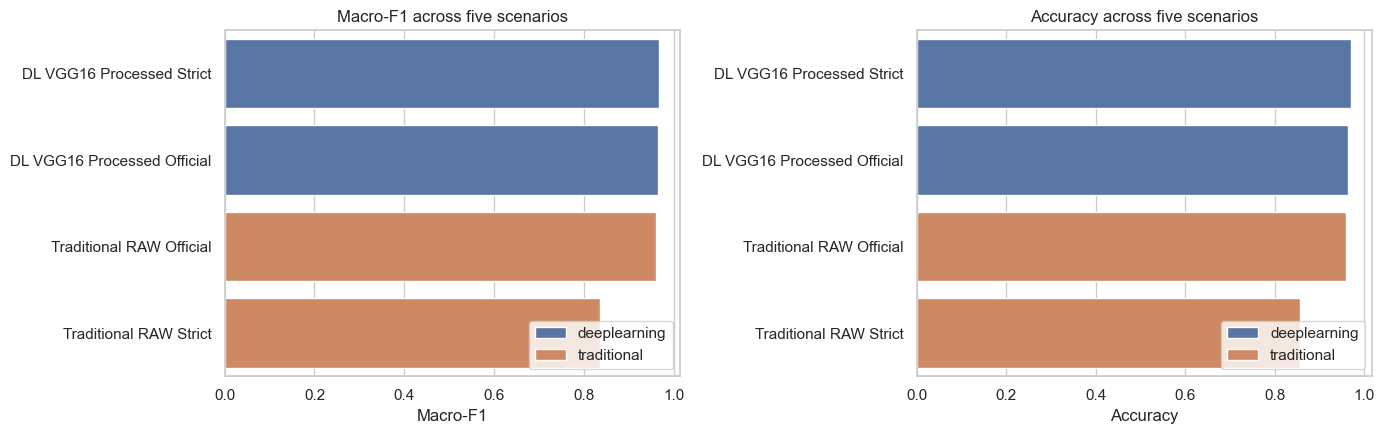

In [50]:
# Five-scenario registry and comparison
SCENARIOS = {
    'trad_raw_official': {
        'label': 'Traditional RAW Official',
        'family': 'traditional',
        'result_candidates': [
            PROJECT_ROOT / 'outputs/tables/final_test_hog_rbf_svm.csv',
            PROJECT_ROOT / 'outputs/runs/traditional/hog/rbf_svm/test_final/seed42_img224/tables/result.csv',
        ],
    },
    'trad_raw_strict': {
        'label': 'Traditional RAW Strict',
        'family': 'traditional',
        'result_candidates': [
            PROJECT_ROOT / 'outputs/tables/final_test_hog_rbf_svm_strict_subset.csv',
            PROJECT_ROOT / 'outputs/runs/traditional/hog/rbf_svm/strict_test_subset/seed42_img224/tables/result.csv',
        ],
    },
    'trad_processed_official': {
        'label': 'Traditional Processed Official',
        'family': 'traditional',
        'result_candidates': [
            PROJECT_ROOT / 'outputs/processed_protocol/tables/final_test_hog_rbf_svm_processed.csv',
            PROJECT_ROOT / 'outputs/runs/traditional/hog/rbf_svm/test_final/seed42_img224_processed/tables/result.csv',
        ],
    },
    'dl_processed_official': {
        'label': 'DL VGG16 Processed Official',
        'family': 'deeplearning',
        'result_candidates': [
            PROJECT_ROOT / 'outputs/tables/result_dl_vgg16_test_final.csv',
            PROJECT_ROOT / 'outputs/runs/deeplearning/vgg16/test_final/seed42_img224_processed/tables/result.csv',
        ],
    },
    'dl_processed_strict': {
        'label': 'DL VGG16 Processed Strict',
        'family': 'deeplearning',
        'result_candidates': [
            PROJECT_ROOT / 'outputs/tables/final_test_dl_vgg16_strict_subset.csv',
            PROJECT_ROOT / 'outputs/runs/deeplearning/vgg16/strict_test_subset/seed42_img224_processed/tables/result.csv',
        ],
    },
}


def pick_existing_path(cands):
    for p in cands:
        if Path(p).exists():
            return Path(p)
    return None


rows = []
for key, info in SCENARIOS.items():
    p = pick_existing_path(info['result_candidates'])
    if p is None:
        rows.append({'scenario': key, 'label': info['label'], 'family': info['family'], 'status': 'missing', 'path': ''})
        continue
    df = pd.read_csv(p)
    if df.empty:
        rows.append({'scenario': key, 'label': info['label'], 'family': info['family'], 'status': 'empty', 'path': str(p)})
        continue
    rec = df.iloc[0].to_dict()
    rec.update({'scenario': key, 'label': info['label'], 'family': info['family'], 'status': 'ok', 'path': str(p)})
    rows.append(rec)

scenario_df = pd.DataFrame(rows)
display(scenario_df[['scenario', 'label', 'family', 'status', 'path']])

ok = scenario_df[scenario_df['status'] == 'ok'].copy()
if not ok.empty:
    for c in ['accuracy', 'macro_f1', 'macro_precision', 'macro_recall']:
        ok[c] = pd.to_numeric(ok[c], errors='coerce')
    show_df = ok.sort_values('macro_f1', ascending=False)
    display(show_df[['label', 'accuracy', 'macro_f1', 'macro_precision', 'macro_recall']])

    fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))
    sns.barplot(data=show_df, x='macro_f1', y='label', hue='family', dodge=False, ax=axes[0])
    axes[0].set_title('Macro-F1 across five scenarios')
    axes[0].set_xlabel('Macro-F1')
    axes[0].set_ylabel('')

    sns.barplot(data=show_df, x='accuracy', y='label', hue='family', dodge=False, ax=axes[1])
    axes[1].set_title('Accuracy across five scenarios')
    axes[1].set_xlabel('Accuracy')
    axes[1].set_ylabel('')

    for ax in axes:
        handles, labels = ax.get_legend_handles_labels()
        if handles:
            ax.legend(handles[:2], labels[:2], loc='lower right')
    plt.tight_layout()
    plt.show()
else:
    print('No scenario results found yet.')


In [51]:
# Select one DL run for detailed explainability
RUN_DIR = PROJECT_ROOT / 'outputs/runs/deeplearning/vgg16/test_final/seed42_img224_processed'
if not RUN_DIR.exists():
    RUN_DIR = PROJECT_ROOT / 'outputs/runs/deeplearning/vgg16/val_final/seed42_img224_processed'

assert RUN_DIR.exists(), f'Run directory not found: {RUN_DIR}'

TABLES_DIR = RUN_DIR / 'tables'
MODELS_DIR = RUN_DIR / 'models'
META_PATH = RUN_DIR / 'metadata.json'
CKPT_PATH = MODELS_DIR / 'best.pt'
assert CKPT_PATH.exists(), f'Checkpoint not found: {CKPT_PATH}'

result_df = pd.read_csv(TABLES_DIR / 'result.csv')
pred_df = pd.read_csv(TABLES_DIR / 'predictions.csv')
history_df = pd.read_csv(TABLES_DIR / 'history.csv')
per_class_df = pd.read_csv(TABLES_DIR / 'per_class.csv')
meta = json.loads(META_PATH.read_text(encoding='utf-8'))

print('RUN_DIR   =', RUN_DIR)
display(result_df)
display(per_class_df)
display(history_df.tail())


RUN_DIR   = /Users/rick/Downloads/Southampton/Computer Vision/CW2/code/Retinal-OCT-Images/outputs/runs/deeplearning/vgg16/test_final/seed42_img224_processed


,feature,classifier,eval_split,accuracy,macro_f1,primary_metric_macro_f1,macro_precision,macro_recall,train_time_sec,inference_time_ms_per_image,notes,model_path,predictions_path,history_path,run_dir
0,end_to_end,vgg16,test_final,0.963843,0.963732,0.963732,0.963997,0.963843,33537.452708,17.953934,best_epoch=8;batch_size=32;image_size=224;data...,/Users/rick/Downloads/Southampton/Computer Vis...,/Users/rick/Downloads/Southampton/Computer Vis...,/Users/rick/Downloads/Southampton/Computer Vis...,/Users/rick/Downloads/Southampton/Computer Vis...


,class_name,precision,recall,f1-score,support
0,CNV,0.969828,0.929752,0.949367,242
1,DME,0.952191,0.987603,0.969574,242
2,DRUSEN,0.954545,0.954545,0.954545,242
3,NORMAL,0.979424,0.983471,0.981443,242


,epoch,train_loss,train_macro_f1,train_accuracy,val_loss,val_macro_f1,val_accuracy
15,16,0.695012,0.753725,0.802507,0.197565,0.949126,0.949380
16,17,0.679454,0.749683,0.798943,0.229699,0.937983,0.939050
17,18,0.671564,0.754784,0.802787,0.201753,0.944609,0.945248
18,19,0.670450,0.755406,0.804380,0.162871,0.957522,0.957645
19,20,0.657856,0.759126,0.807133,0.185343,0.943724,0.944215


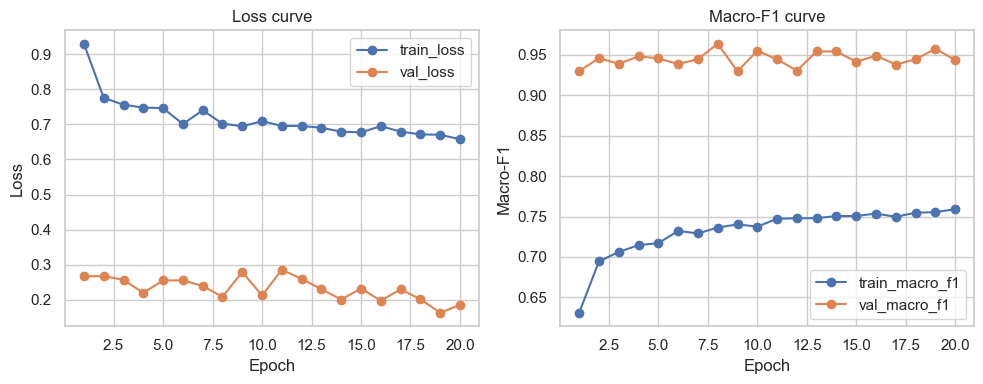

In [52]:
# Training curves
plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
plt.plot(history_df['epoch'], history_df['train_loss'], marker='o', label='train_loss')
plt.plot(history_df['epoch'], history_df['val_loss'], marker='o', label='val_loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Loss curve')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history_df['epoch'], history_df['train_macro_f1'], marker='o', label='train_macro_f1')
plt.plot(history_df['epoch'], history_df['val_macro_f1'], marker='o', label='val_macro_f1')
plt.xlabel('Epoch')
plt.ylabel('Macro-F1')
plt.title('Macro-F1 curve')
plt.legend()
plt.tight_layout()
plt.show()


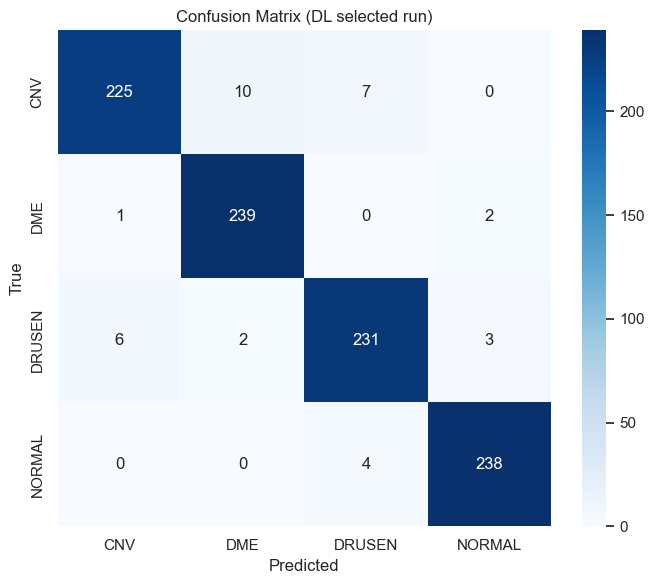

Macro ROC-AUC (OVR): 0.9957


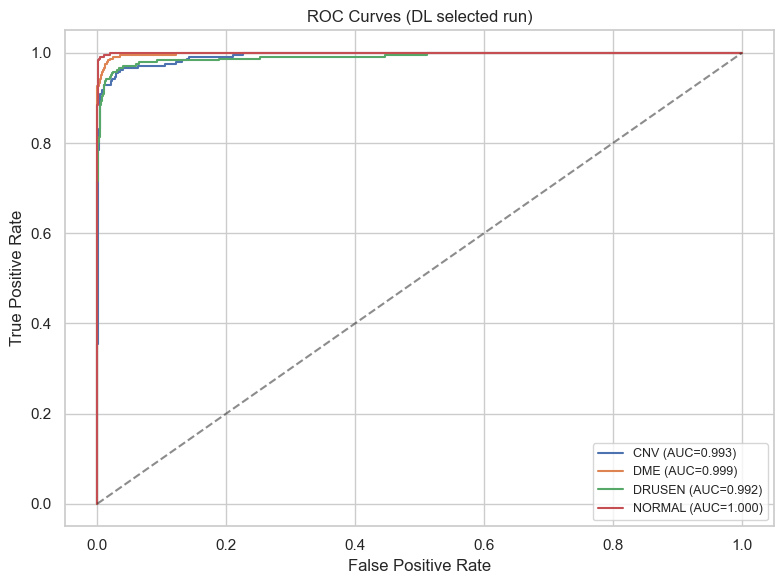

In [ ]:
# Confusion matrix + ROC (dynamic title)

from pathlib import Path

# Optional manual override:
# SCENARIO_NAME = "DL VGG16 (processed, official test_final)"

def infer_scenario_name():
    if "SCENARIO_NAME" in globals() and SCENARIO_NAME:
        return str(SCENARIO_NAME)
    if "RUN_DIR" in globals():
        p = Path(str(RUN_DIR))
        parts = p.parts
        model = "unknown_model"
        split = "unknown_split"
        tag = p.name  # e.g. seed42_img224_processed
        if "deeplearning" in parts:
            i = parts.index("deeplearning")
            if i + 1 < len(parts):
                model = parts[i + 1]
            if i + 2 < len(parts):
                split = parts[i + 2]
        return f"{model} | {split} | {tag}"
    return "DL run"

scenario_name = infer_scenario_name()

y_true = pred_df["y_true"].to_numpy()
y_pred = pred_df["y_pred"].to_numpy()
prob_cols = [f"prob_{c}" for c in CLASS_NAMES]
if not all(c in pred_df.columns for c in prob_cols):
    raise RuntimeError(f"Probability columns missing. Expected: {prob_cols}")
prob_mat = pred_df[prob_cols].to_numpy()

cm = confusion_matrix(y_true, y_pred, labels=CLASS_NAMES)
plt.figure(figsize=(7, 6))
sns.heatmap(
    cm, annot=True, fmt="d", cmap="Blues",
    xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES
)
plt.title(f"Confusion Matrix ({scenario_name})")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.tight_layout()
plt.show()

y_true_bin = label_binarize(y_true, classes=CLASS_NAMES)
auc_macro = roc_auc_score(y_true_bin, prob_mat, average="macro", multi_class="ovr")
print(f"Scenario: {scenario_name}")
print(f"Macro ROC-AUC (OVR): {auc_macro:.4f}")

plt.figure(figsize=(8, 6))
for i, cls in enumerate(CLASS_NAMES):
    fpr, tpr, _ = roc_curve(y_true_bin[:, i], prob_mat[:, i])
    plt.plot(fpr, tpr, label=f"{cls} (AUC={auc(fpr, tpr):.3f})")
plt.plot([0, 1], [0, 1], "k--", alpha=0.5)
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title(f"ROC Curves ({scenario_name})")
plt.legend(loc="lower right", fontsize=9)
plt.tight_layout()
plt.show()


In [54]:
# CELL A: Load model + stable Grad-CAM/IG utilities (VGG-safe)
import torch
import torch.nn as nn
import cv2
import numpy as np
from PIL import Image

device = "mps" if (hasattr(torch.backends, "mps") and torch.backends.mps.is_available()) else "cpu"
model_name = str(meta.get("model", result_df.loc[0, "classifier"]))
image_size = int(meta.get("image_size", 224))

model = build_model(
    model_name=model_name,
    num_classes=len(CLASS_NAMES),
    pretrained=False,
    freeze_backbone=False,
)
ckpt = torch.load(CKPT_PATH, map_location=device, weights_only=False)
model.load_state_dict(ckpt["model_state_dict"])

# Disable inplace ReLU to avoid backward hook/view conflicts in VGG
for m in model.modules():
    if isinstance(m, nn.ReLU):
        m.inplace = False

model.to(device).eval()
eval_transform = build_transforms(image_size=image_size, augment=False)

def denorm_image(t):
    mean = torch.tensor(IMAGENET_MEAN, device=t.device).view(3, 1, 1)
    std = torch.tensor(IMAGENET_STD, device=t.device).view(3, 1, 1)
    img = (t * std + mean).clamp(0, 1)
    return img.detach().cpu().permute(1, 2, 0).numpy()

def find_last_conv_layer(m):
    for x in reversed(list(m.modules())):
        if isinstance(x, nn.Conv2d):
            return x
    raise RuntimeError("No Conv2d layer found for Grad-CAM.")

# Hook-safe Grad-CAM (no register_full_backward_hook)
def gradcam(m, x, target_idx=None):
    m.eval()
    layer = find_last_conv_layer(m)
    acts = []

    def fwd_hook(_m, _in, out):
        acts.append(out)

    h = layer.register_forward_hook(fwd_hook)

    logits = m(x)
    if target_idx is None:
        target_idx = int(torch.argmax(logits, dim=1).item())

    grads = torch.autograd.grad(
        outputs=logits[0, target_idx],
        inputs=acts[0],
        retain_graph=False,
        create_graph=False,
    )[0]

    a = acts[0][0]      # [C,H,W]
    g = grads[0]        # [C,H,W]
    w = g.mean(dim=(1, 2), keepdim=True)
    cam = torch.relu((w * a).sum(dim=0))
    cam = cam - cam.min()
    cam = cam / (cam.max() + 1e-8)

    h.remove()
    return cam.detach().cpu().numpy(), target_idx

def integrated_gradients(m, x, target_idx, steps=50):
    baseline = torch.zeros_like(x)
    alphas = torch.linspace(0.0, 1.0, steps + 1, device=x.device).view(-1, 1, 1, 1)
    total_grad = torch.zeros_like(x)

    for alpha in alphas:
        xi = baseline + alpha * (x - baseline)
        xi.requires_grad_(True)
        logits = m(xi)
        score = logits[0, target_idx]
        m.zero_grad(set_to_none=True)
        score.backward()
        total_grad += xi.grad.detach()

    avg_grad = total_grad / float(steps + 1)
    attr = (x - baseline) * avg_grad
    attr = attr.abs().sum(dim=1)[0]
    attr = attr - attr.min()
    attr = attr / (attr.max() + 1e-8)
    return attr.detach().cpu().numpy()

print("device =", device, "model =", model_name, "image_size =", image_size)


device = mps model = vgg16 image_size = 224


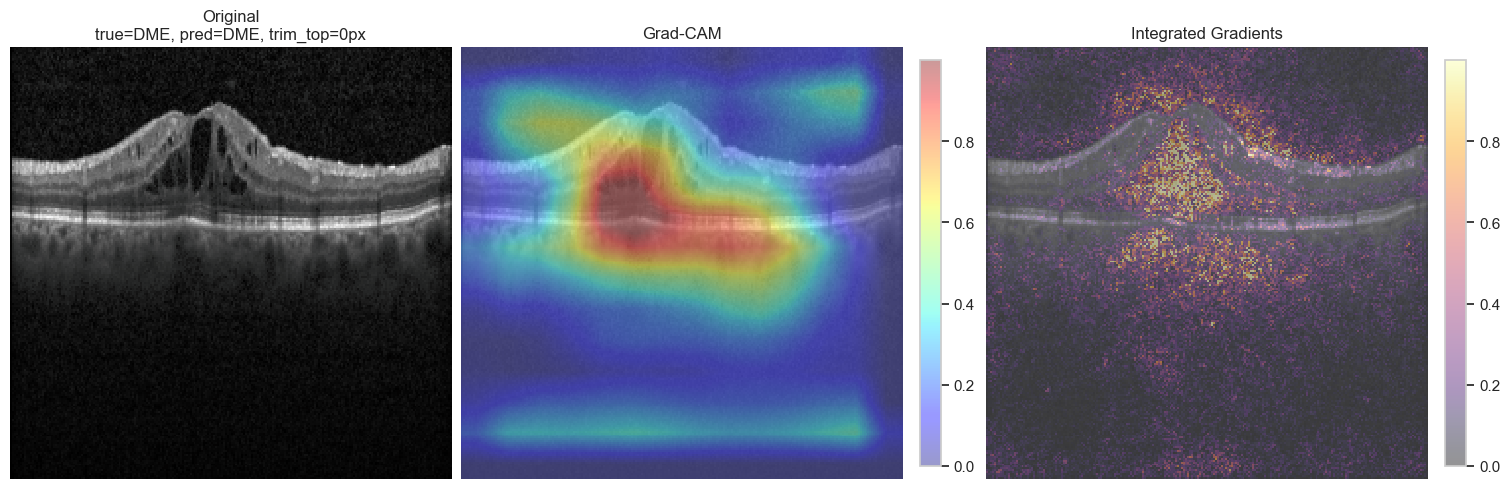

In [69]:
# --- display helpers (visualization only) ---
def robust_minmax(x, lo=2, hi=98):
    a = np.asarray(x, dtype=np.float32)
    v1, v2 = np.percentile(a, [lo, hi])
    a = np.clip(a, v1, v2)
    return (a - a.min()) / (a.max() - a.min() + 1e-8)

def auto_trim_top_band(img_rgb, cam=None, ig=None, max_trim=32):
    """
    仅用于显示：自动裁掉顶部边界亮带（若检测到）。
    """
    g = img_rgb.mean(axis=2) if img_rgb.ndim == 3 else img_rgb
    row_mean = g.mean(axis=1)
    ref = row_mean[:8].mean()
    diff = np.abs(row_mean - ref)

    # 找到从“顶部背景带”进入“有效内容区”的位置
    thr = diff[:max_trim].mean() + 1.5 * diff[:max_trim].std()
    idx = np.where(diff[:max_trim] > thr)[0]
    top = int(max(0, idx[0] - 2)) if len(idx) else 0

    img2 = img_rgb[top:, :]
    cam2 = cam[top:, :] if cam is not None else None
    ig2 = ig[top:, :] if ig is not None else None
    return img2, cam2, ig2, top

# Explain one fixed sample (manually selected, non-tilted)
sample_path = "/Users/rick/Downloads/Southampton/Computer Vision/CW2/code/Retinal-OCT-Images/data/processed/oct224_gray_png_v2/test_final/DME/DME-323904-1.png"
candidate = pred_df[pred_df["filepath"] == sample_path].head(1)
assert not candidate.empty, f"Sample not found in pred_df: {sample_path}"


sample_path = candidate.iloc[0]['filepath']
sample_true = candidate.iloc[0]['y_true']
sample_pred = candidate.iloc[0]['y_pred']

img_pil = Image.open(sample_path)
x = eval_transform(img_pil).unsqueeze(0).to(device)

cam, target_idx = gradcam(model, x, target_idx=None)
ig = integrated_gradients(model, x, target_idx=target_idx, steps=50)

img_show = denorm_image(x[0])  # HxWxC in [0,1]
cam_r = cv2.resize(cam.astype(np.float32), (img_show.shape[1], img_show.shape[0]))
ig_r = cv2.resize(ig.astype(np.float32), (img_show.shape[1], img_show.shape[0]))

# 1) 自动去掉顶部亮带（仅显示）
img_show, cam_r, ig_r, top_trim = auto_trim_top_band(img_show, cam_r, ig_r, max_trim=32)

# 2) 稳定色阶，避免“整片一色”或噪点过爆
cam_v = robust_minmax(cam_r, 5, 99)
ig_v = robust_minmax(np.abs(ig_r), 5, 99)

fig, axes = plt.subplots(1, 3, figsize=(15, 4.8), constrained_layout=True)

axes[0].imshow(img_show, cmap='gray', aspect='auto', interpolation='nearest')
axes[0].set_title(f'Original\ntrue={sample_true}, pred={sample_pred}, trim_top={top_trim}px')
axes[0].axis('off')

axes[1].imshow(img_show, cmap='gray', alpha=0.60, aspect='auto', interpolation='nearest')
im1 = axes[1].imshow(cam_v, cmap='jet', alpha=0.40, aspect='auto', interpolation='nearest')
axes[1].set_title('Grad-CAM')
axes[1].axis('off')
plt.colorbar(im1, ax=axes[1], fraction=0.046, pad=0.04)

axes[2].imshow(img_show, cmap='gray', alpha=0.62, aspect='auto', interpolation='nearest')
im2 = axes[2].imshow(ig_v, cmap='inferno', alpha=0.42, aspect='auto', interpolation='nearest')
axes[2].set_title('Integrated Gradients')
axes[2].axis('off')
plt.colorbar(im2, ax=axes[2], fraction=0.046, pad=0.04)

plt.show()
